# Load modules

In [1]:
# load public modules

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from scipy.interpolate import griddata
import cmocean
from cmcrameri import cm
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import cftime
import pop_tools
from pprint import pprint
import time
import subprocess
import re as re_mod
import cftime
import datetime
from scipy.stats import ttest_1samp
# from scipy.stats import pearsonr
from scipy.stats import t

In [2]:
# load private modules

import sys
sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')
from KYY_CESM2_preprocessing import CESM2_config
# import KYY_CESM2_preprocessing
# import importlib
# importlib.reload(KYY_CESM2_preprocessing)

# Variable configuration

In [3]:
cfg_var=CESM2_config()
cfg_var.year_s=1960
cfg_var.year_e=2020

cfg_var.setvar('SST')
cfg_var.list()

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

{'codebase': 'e21',
 'comp': 'atm',
 'compset': 'b',
 'dimension': 'time '
              'lat '
              'lon',
 'long_name': 'sea '
              'surface '
              'temperature',
 'model': 'cam.h0',
 'ndim': 3,
 'resol': 'f09_g17',
 'tfreq': 'month_1',
 'unit': 'K',
 'var': 'SST',
 'year_e': 2020,
 'year_s': 1960}


# Read dataset

In [32]:
# define preprocessing function

exceptcv=['time','lon','lat','TLONG', 'TLAT', 'z_w', cfg_var.var]
def process_coords(ds, sd, ed, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
    ds['lat'] = np.round(ds['lat'], 5)
    ds['lon'] = np.round(ds['lon'], 5)
    if drop:
        ds= ds.drop(coord_vars)
        ds= ds.sel(time=slice(sd, ed))
        return ds
    else:
        return ds.set_coords(coord_vars)


start_date = cftime.DatetimeNoLeap(cfg_var.year_s, 2, 1)
end_date = cftime.DatetimeNoLeap(cfg_var.year_e+1, 1, 1)


def process_coords_hcst(ds, drop=True, except_coord_vars=['time','lon','lat', 'TLONG', 'TLAT', cfg_var.var]):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
    ds['lat'] = np.round(ds['lat'], 5)
    ds['lon'] = np.round(ds['lon'], 5)

    if drop:
        ds= ds.drop(coord_vars)
        return ds
    else:
        return ds.set_coords(coord_vars)

In [33]:
# Read Hindcast dataset
start_time = time.time()

cfg_var.HCST_path_load(cfg_var.var)

cfg_var.HCST_ds = []
for iyear in range(0, len(cfg_var.HCST_file_list)):
    file_list = [f[0] for f in cfg_var.HCST_file_list[iyear]]
    HCST_ds_tmp = xr.open_mfdataset(file_list, 
                           chunks={'time': 1}, 
                           combine='nested',
                           # concat_dim=[[*cfg_var.HCST_ensembles]], 
                           concat_dim='ensemble', 
                           parallel=False,
                           preprocess=lambda ds: process_coords_hcst(ds),
                           decode_cf=True, 
                           decode_times=True)
    HCST_ds_tmp['time_values'] = HCST_ds_tmp['time'].values
    HCST_ds_tmp = HCST_ds_tmp.rename({"time": "lmonths"})
    HCST_ds_tmp['lmonths']=range(1,61)
    HCST_ds_tmp = HCST_ds_tmp.assign(time_values=("lmonths", HCST_ds_tmp['time_values'].values))  # time 값을 lmonths 차원과 연결

    HCST_ds_tmp
    
    HCST_ds_a= []
    HCST_ds_a.append(HCST_ds_tmp)
    HCST_ds_xr = xr.concat(HCST_ds_a, dim='lmonths')
    HCST_ds_xr = HCST_ds_xr.expand_dims({'iyear': 1})
    
    cfg_var.HCST_ds.append(HCST_ds_xr)

cfg_var.HCST_ds = xr.concat(cfg_var.HCST_ds, dim='iyear')
cfg_var.HCST_ds = cfg_var.HCST_ds.rename({"ensemble": "ens_HCST"})
cfg_var.HCST_ds['iyear']=range(cfg_var.year_s, cfg_var.year_e+1)

# time_values의 차원에 맞는 timedelta 배열 생성
timedelta_array = np.full(cfg_var.HCST_ds.time_values.shape, datetime.timedelta(days=15))
# time_values에서 15일을 뺀 새로운 time_values 생성
new_time = cfg_var.HCST_ds.time_values - timedelta_array
# 새로운 time_values로 업데이트
cfg_var.HCST_ds = cfg_var.HCST_ds.assign(time_values=new_time)

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for reading HCST: ' + str(elapsed_time))

elasped time for reading HCST: 54.51695537567139


In [35]:
# Read LE dataset

start_time = time.time()


cfg_var.LE_path_load(cfg_var.var)
cfg_var.LE_ds = xr.open_mfdataset(cfg_var.LE_file_list[0], 
                       chunks={'time': 1}, 
                       combine='nested', 
                       concat_dim=[[*cfg_var.LE_ensembles], 'time'], 
                       parallel=False,
                       preprocess=lambda ds: process_coords(ds, start_date, end_date),
                       decode_cf=True, 
                       decode_times=True)      


cfg_var.LE_ds = cfg_var.LE_ds.rename({"concat_dim": "ens_LE"})
new_time = cfg_var.LE_ds.time - np.array([datetime.timedelta(days=15)] * len(cfg_var.LE_ds.time))
cfg_var.LE_ds = cfg_var.LE_ds.assign_coords(time=new_time)

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for reading LE: ' + str(elapsed_time))

elasped time for reading LE: 19.074540615081787


In [36]:
# Read ODA dataset (all)

start_time = time.time()

cfg_var.ODA_path_load(cfg_var.var)

ODA_ds = xr.open_mfdataset(cfg_var.ODA_file_list[0][0:10],
                           chunks={'time': 1}, 
                           combine='nested', 
                           concat_dim=[[*cfg_var.ODA_ensembles[0:10]], 'time'], 
                           parallel=False,
                           preprocess=lambda ds: process_coords(ds, start_date, end_date),
                           decode_cf=True, 
                           decode_times=True)

ODA_ds2 = xr.open_mfdataset(cfg_var.ODA_file_list[0][10:20], 
                           chunks={'time': 1}, 
                           combine='nested', 
                           concat_dim=[[*cfg_var.ODA_ensembles[10:20]], 'time'], 
                           parallel=False,
                           preprocess=lambda ds: process_coords(ds, start_date, end_date),
                           decode_cf=True, 
                           decode_times=True)

# en4.2 -> until 2021; projdv7.3 -> until 2020; need to be read separately
ODA_ds_a = []
ODA_ds_a.append(ODA_ds)
ODA_ds_xr = xr.concat(ODA_ds_a, dim='time')
ODA_ds_xr = ODA_ds_xr.expand_dims({'ens': range(10)})

ODA_ds2_a = []
ODA_ds2_a.append(ODA_ds2)
ODA_ds2_xr = xr.concat(ODA_ds2_a, dim='time')
ODA_ds2_xr = ODA_ds2_xr.expand_dims({'ens': range(10, 20)})

cfg_var.ODA_ds = []
cfg_var.ODA_ds.append(ODA_ds_xr)
cfg_var.ODA_ds.append(ODA_ds2_xr)
cfg_var.ODA_ds = xr.concat(cfg_var.ODA_ds, dim='ens')
cfg_var.ODA_ds = cfg_var.ODA_ds.reindex(ens=list(range(1, 20+1)))
cfg_var.ODA_ds = cfg_var.ODA_ds.sortby('time')

cfg_var.ODA_ds = cfg_var.ODA_ds.rename({"concat_dim": "ens_ODA"})
new_time = cfg_var.ODA_ds.time - np.array([datetime.timedelta(days=15)] * len(cfg_var.ODA_ds.time))
cfg_var.ODA_ds = cfg_var.ODA_ds.assign_coords(time=new_time)
cfg_var.ODA_ds = cfg_var.ODA_ds.drop('ens')
cfg_var.ODA_ds=cfg_var.ODA_ds.mean(dim='ens')
end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for reading ODA: ' + str(elapsed_time))

elasped time for reading ODA: 9.43670916557312


In [37]:
#Read ADA dataset
start_time = time.time()

cfg_var.ADA_path_load(cfg_var.var)
cfg_var.ADA_ds = xr.open_mfdataset(cfg_var.ADA_file_list[0], 
                       chunks={'time': 1}, 
                       combine='nested',
                       concat_dim=[[*cfg_var.ADA_ensembles], 'time'], 
                       parallel=False,
                       preprocess=lambda ds: process_coords(ds, start_date, end_date),
                       decode_cf=True, 
                       decode_times=True)      


cfg_var.ADA_ds = cfg_var.ADA_ds.rename({"concat_dim": "ens_ADA"})
new_time = cfg_var.ADA_ds.time - np.array([datetime.timedelta(days=15)] * len(cfg_var.ADA_ds.time))
cfg_var.ADA_ds = cfg_var.ADA_ds.assign_coords(time=new_time)

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for reading ADA: ' + str(elapsed_time))

elasped time for reading ADA: 4.098484992980957


In [38]:
# # Read ODA dataset (projd only)
# start_time = time.time()

# cfg_var.ODA_path_load(cfg_var.var)

# cfg_var.ODA_ds = xr.open_mfdataset(cfg_var.ODA_file_list[0][10:20], 
#                            chunks={'time': 2}, 
#                            combine='nested', 
#                            concat_dim=[[*cfg_var.ODA_ensembles[10:20]], 'time'], 
#                            parallel=False,
#                            preprocess=lambda ds: process_coords(ds, start_date, end_date),
#                            decode_cf=True, 
#                            decode_times=True)

# cfg_var.ODA_ds = cfg_var.ODA_ds.rename({"concat_dim": "ens_ODA"})
# new_time = cfg_var.ODA_ds.time - np.array([datetime.timedelta(days=15)] * len(cfg_var.ODA_ds.time))
# cfg_var.ODA_ds = cfg_var.ODA_ds.assign_coords(time=new_time)

# end_time = time.time()
# elapsed_time = end_time - start_time
# print('elasped time for reading ODA: ' + str(elapsed_time))

In [39]:
# Read Observation dataset
start_time = time.time()

cfg_var.OBS_path_load(cfg_var.var)
# cfg_var.OBS_ds = xr.open_mfdataset(cfg_var.OBS_file_list[0][0], 
#                        combine='nested',
#                        concat_dim= 'time',
#                        chunks={'time': 6}, 
#                        parallel=False,
#                        preprocess=lambda ds: process_coords(ds, start_date, end_date),
#                        decode_cf=True, 
#                        decode_times=True,
#                        engine='h5netcdf')
cfg_var.OBS_ds = xr.open_mfdataset(cfg_var.OBS_file_list[0][0], 
                       chunks={'time': 1}, 
                       parallel=False,
                       decode_cf=True, 
                       decode_times=True,)
cfg_var.OBS_ds = cfg_var.OBS_ds.rename({cfg_var.OBS_var: cfg_var.var})

if cfg_var.var=='SSH':
    cfg_var.OBS_ds=cfg_var.OBS_ds.assign_coords(time=cfg_var.ODA_ds.time[396:732])
# elif cfg_var.var=='SST':
#     cfg_var.OBS_ds=cfg_var.OBS_ds.assign_coords(time=cfg_var.ODA_ds.time[456:732])
cfg_var.OBS_ds=cfg_var.OBS_ds.assign_coords(time=cfg_var.ODA_ds.time)

# global mean removal for SSH
if cfg_var.var=='SSH':
    lat_mask = (ds_grid.TLAT >= -60) & (ds_grid.TLAT <= 60)

    area_selected = ds_grid.TAREA.where(lat_mask, drop=True)  # 선택된 지역의 면적
    ssh_selected = cfg_var.OBS_ds[cfg_var.var].where(lat_mask, drop=True)  # 선택된 지역의 SSH 데이터

    # 필터링된 지역에 대해 global mean 계산
    cfg_var.OBS_ds['gm'] = (ssh_selected * area_selected).sum(dim=['nlat', 'nlon']) / area_selected.sum(dim=['nlat', 'nlon'])
    
    # 원 데이터에서 global mean을 제거한 값
    cfg_var.OBS_ds['SSH'] = cfg_var.OBS_ds[cfg_var.var] - cfg_var.OBS_ds['gm']


# Step 1: 결측값이 아닌 값의 비율 계산
# 결측값이 아닌 값들에 대해 True, 결측값에 대해 False로 표시
valid_data_count = (~cfg_var.OBS_ds['SST'].isnull()).sum(dim='time')
# Step 2: 전체 시간 축의 길이 (즉, 데이터가 있어야 할 총 시간 개수)
total_time_steps = cfg_var.OBS_ds['time'].size
# Step 3: 80% 이상의 값이 있는지 계산
# 비율 계산 후, 80% 이상이면 True, 그렇지 않으면 False로 표시
threshold = 0.8
mask = (valid_data_count / total_time_steps) >= threshold
# Step 4: 마스크 변수를 데이터셋에 추가
cfg_var.OBS_ds['mask_80_percent'] = mask
cfg_var.OBS_ds['mask_80_percent'].compute()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for reading OBS: ' + str(elapsed_time))

elasped time for reading OBS: 7.289246559143066


# Take annual means

In [40]:
# obs_non_nan_times = cfg_var.OBS_ds.notnull()
# ada_filtered = cfg_var.ADA_ds.sel(time=obs_non_nan_times)

# Step 1: OBS_ds에서 NaN이 아닌 시간대에 해당하는 boolean mask 생성
# obs_non_nan_times = cfg_var.OBS_ds[cfg_var.var].notnull().any(dim=['nlat', 'nlon'])
obs_non_nan_times = cfg_var.OBS_ds[cfg_var.var].notnull().any(dim=['lat', 'lon'])

# Step 2: boolean mask를 명시적으로 계산 (compute() 호출)
obs_non_nan_times = obs_non_nan_times.compute()
# Step 3: NaN이 아닌 시간대에 해당하는 time 좌표 추출
non_nan_time_coords = cfg_var.OBS_ds.time.where(obs_non_nan_times, drop=True)
# Step 4: ADA_ds에서 NaN이 아닌 시간대에 해당하는 자료만 선택
oda_filtered = cfg_var.ODA_ds.sel(time=non_nan_time_coords)
le_filtered = cfg_var.LE_ds.sel(time=non_nan_time_coords)
ada_filtered = cfg_var.ADA_ds.sel(time=non_nan_time_coords)

# Step 5: 연도별로 그룹화하고 NaN을 무시한 연평균 계산
ada_annual_mean = ada_filtered.groupby('time.year').mean(dim='time', skipna=True)
oda_annual_mean = oda_filtered.groupby('time.year').mean(dim='time', skipna=True)
le_annual_mean = le_filtered.groupby('time.year').mean(dim='time', skipna=True)
obs_annual_mean = cfg_var.OBS_ds.groupby('time.year').mean(dim='time', skipna=True)

oda_full_annual_mean = cfg_var.ODA_ds.groupby('time.year').mean(dim='time', skipna=True)
le_full_annual_mean = cfg_var.LE_ds.groupby('time.year').mean(dim='time', skipna=True)
ada_full_annual_mean = cfg_var.ADA_ds.groupby('time.year').mean(dim='time', skipna=True)

ref_time=cfg_var.ODA_ds.time.groupby('time.year').mean(dim='time')

In [41]:
# 4 year moving average
oda_rolling_mean = oda_annual_mean.rolling(year=4, min_periods=4).mean()
oda_rolling_time_mean = oda_annual_mean['year'].rolling(year=4, min_periods=4).mean()
oda_rolling_mean = oda_rolling_mean.assign_coords(year=oda_rolling_time_mean)
valid_index = np.where(~np.isnan(oda_rolling_mean['year']))[0]
oda_rolling_mean = oda_rolling_mean.isel(year=valid_index)

ada_rolling_mean = ada_annual_mean.rolling(year=4, min_periods=4).mean()
ada_rolling_time_mean = ada_annual_mean['year'].rolling(year=4, min_periods=4).mean()
ada_rolling_mean = ada_rolling_mean.assign_coords(year=ada_rolling_time_mean)
valid_index = np.where(~np.isnan(ada_rolling_mean['year']))[0]
ada_rolling_mean = ada_rolling_mean.isel(year=valid_index)

le_rolling_mean = le_annual_mean.rolling(year=4, min_periods=4).mean()
le_rolling_time_mean = le_annual_mean['year'].rolling(year=4, min_periods=4).mean()
le_rolling_mean = le_rolling_mean.assign_coords(year=le_rolling_time_mean)
valid_index = np.where(~np.isnan(le_rolling_mean['year']))[0]
le_rolling_mean = le_rolling_mean.isel(year=valid_index)

obs_rolling_mean = obs_annual_mean.rolling(year=4, min_periods=4).mean()
obs_rolling_time_mean = obs_annual_mean['year'].rolling(year=4, min_periods=4).mean()
obs_rolling_mean = obs_rolling_mean.assign_coords(year=obs_rolling_time_mean)
valid_index = np.where(~np.isnan(obs_rolling_mean['year']))[0]
obs_rolling_mean = obs_rolling_mean.isel(year=valid_index)

oda_full_rolling_mean = oda_full_annual_mean.rolling(year=4, min_periods=4).mean()
oda_full_rolling_time_mean = oda_full_annual_mean['year'].rolling(year=4, min_periods=4).mean()
oda_full_rolling_mean = oda_full_rolling_mean.assign_coords(year=oda_full_rolling_time_mean)
valid_index = np.where(~np.isnan(oda_full_rolling_mean['year']))[0]
oda_full_rolling_mean = oda_full_rolling_mean.isel(year=valid_index)

ada_full_rolling_mean = ada_full_annual_mean.rolling(year=4, min_periods=4).mean()
ada_full_rolling_time_mean = ada_full_annual_mean['year'].rolling(year=4, min_periods=4).mean()
ada_full_rolling_mean = ada_full_rolling_mean.assign_coords(year=ada_full_rolling_time_mean)
valid_index = np.where(~np.isnan(ada_full_rolling_mean['year']))[0]
ada_full_rolling_mean = ada_full_rolling_mean.isel(year=valid_index)

le_full_rolling_mean = le_full_annual_mean.rolling(year=4, min_periods=4).mean()
le_full_rolling_time_mean = le_full_annual_mean['year'].rolling(year=4, min_periods=4).mean()
le_full_rolling_mean = le_full_rolling_mean.assign_coords(year=le_full_rolling_time_mean)
valid_index = np.where(~np.isnan(le_full_rolling_mean['year']))[0]
le_full_rolling_mean = le_full_rolling_mean.isel(year=valid_index)

In [42]:
hcst_annual_mean = cfg_var.HCST_ds.groupby((cfg_var.HCST_ds.lmonths - 1) // 12).mean(dim='lmonths')
# 새로운 차원 이름을 원하는 대로 수정 (여기서는 'year')
hcst_annual_mean = hcst_annual_mean.rename({'lmonths': 'lyear'})

In [43]:
hcst_ly1_annual_mean = hcst_annual_mean[cfg_var.var].isel(lyear=0)
hcst_ly1_annual_mean = hcst_ly1_annual_mean.rename({'iyear': 'year'})
hcst_ly1_annual_mean= hcst_ly1_annual_mean.assign_coords(year=ref_time.year)
hcst_full_ly1_annual_mean = hcst_ly1_annual_mean
hcst_ly1_annual_mean = hcst_ly1_annual_mean.sel(year=obs_annual_mean.year)

In [44]:

hcst_ly2_5_annual_mean = hcst_annual_mean[cfg_var.var].isel(lyear=slice(1, 5)) # except of 0, 1:4 is selected
hcst_ly2_5_annual_mean=hcst_ly2_5_annual_mean.mean(dim='lyear')
hcst_ly2_5_annual_mean = hcst_ly2_5_annual_mean.rename({'iyear': 'year'})
hcst_ly2_5_annual_mean= hcst_ly2_5_annual_mean.assign_coords(year=ref_time.year + (1+4)/2)
hcst_full_ly2_5_annual_mean = hcst_ly2_5_annual_mean
common_years = np.intersect1d(
    hcst_ly2_5_annual_mean.year,
    obs_rolling_mean.year
)
hcst_ly2_5_annual_mean = hcst_ly2_5_annual_mean.sel(year=common_years)

In [45]:
# take ensemble mean, for increments (ODA-LE, HCST-LE)

oda_annual_mean['enm']=oda_annual_mean[cfg_var.var].mean(dim='ens_ODA')
le_annual_mean['enm']=le_annual_mean[cfg_var.var].mean(dim='ens_LE')
# hcst_annual_mean['enm']=hcst_ly1_annual_mean.mean(dim='ens_HCST')

oda_full_annual_mean['enm']=oda_full_annual_mean[cfg_var.var].mean(dim='ens_ODA')
le_full_annual_mean['enm']=le_full_annual_mean[cfg_var.var].mean(dim='ens_LE')

oda_annual_mean['diff_le']=oda_annual_mean[cfg_var.var] - le_annual_mean.enm
ada_annual_mean['diff_le']=ada_annual_mean[cfg_var.var] - le_annual_mean.enm
ada_annual_mean['diff_oda']=ada_annual_mean[cfg_var.var] - oda_annual_mean.enm

oda_full_annual_mean['diff_le']=oda_full_annual_mean[cfg_var.var] - le_full_annual_mean.enm
ada_full_annual_mean['diff_le']=ada_full_annual_mean[cfg_var.var] - le_full_annual_mean.enm
ada_full_annual_mean['diff_oda']=ada_full_annual_mean[cfg_var.var] - oda_full_annual_mean.enm

In [46]:
oda_full_rolling_mean['enm']=oda_full_rolling_mean[cfg_var.var].mean(dim='ens_ODA')

In [47]:
hcst_full_ly1_annual_mean['enm']=hcst_full_ly1_annual_mean.mean(dim='ens_HCST')
hcst_ly1_annual_mean['enm']=hcst_ly1_annual_mean.mean(dim='ens_HCST')
hcst_full_ly2_5_annual_mean['enm']=hcst_full_ly2_5_annual_mean.mean(dim='ens_HCST')
hcst_ly2_5_annual_mean['enm']=hcst_ly2_5_annual_mean.mean(dim='ens_HCST')

In [48]:
start_time = time.time()

# corr_ODA_diff = xr.corr(oda_annual_mean.diff_le, getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# corr_ADA_diff_le = xr.corr(ada_annual_mean.diff_le, getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# corr_ADA_diff_oda = xr.corr(ada_annual_mean.diff_oda, getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# # corr_LE = xr.corr(le_annual_mean[cfg_var.var], getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# # corr_ODA = xr.corr(oda_annual_mean[cfg_var.var], getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# corr_HCST = xr.corr(hcst_ly1_annual_mean, getattr(obs_annual_mean,cfg_var.var), dim='year').compute()
# corr_HCST_ly2_5 = xr.corr(hcst_ly2_5_annual_mean, getattr(obs_rolling_mean,cfg_var.var), dim='year').compute()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for calculating correlation: ' + str(elapsed_time))

elasped time for calculating correlation: 2.193450927734375e-05


In [49]:
# da = cfg_var.ODA_ds['SST']

# for e in range(da.sizes['ens_ODA']):
#     for t in range(da.sizes['time']):
#         try:
#             da.isel(ens_ODA=e, time=t).load()
#         except Exception as e_msg:
#             print("\n💥 ERROR DETECTED")
#             print("ens_ODA:", e)
#             print("time index:", t)
#             print("ERROR:", e_msg)
#             break

In [50]:
import xarray as xr
import numpy as np

############################################################
# 1. 깨진 chunk 자동 탐지
############################################################
def detect_broken_chunks(da, dim_time='time', dim_ens='ens_ODA', var_name=None):
    broken = []

    print("\n🔍 Detecting broken chunks...\n")

    for e in range(da.sizes[dim_ens]):
        for t in range(da.sizes[dim_time]):
            try:
                da.isel({dim_ens: e, dim_time: t}).load()
            except Exception as err:
                print(f"💥 Broken → ens={e}, time_idx={t}")
                broken.append((e, t))

    print(f"\nTotal broken points: {len(broken)}")
    return broken


############################################################
# 2. 깨진 time / ensemble 자동 정리
############################################################
def summarize_broken(broken):
    if not broken:
        return [], []

    broken_ens = sorted(set(e for e, t in broken))
    broken_time = sorted(set(t for e, t in broken))

    print("\n📊 Summary")
    print("Broken ens:", broken_ens)
    print("Broken time idx:", broken_time)

    return broken_ens, broken_time


############################################################
# 3. safe loader (깨진 부분 자동 skip)
############################################################
def build_clean_dataset(da, dim_time='time', dim_ens='ens_ODA'):
    clean_list = []

    print("\n🛠 Building clean dataset...\n")

    for t in range(da.sizes[dim_time]):
        try:
            tmp = da.isel({dim_time: t}).load()
            clean_list.append(tmp)
        except Exception:
            print(f"⚠️ Skipping corrupted time index: {t}")

    da_clean = xr.concat(clean_list, dim=dim_time)

    print("\n✅ Clean dataset created")
    return da_clean


############################################################
# 4. FULL PIPELINE
############################################################
def clean_da(da, dim_time='time', dim_ens='ens_ODA'):

    # 1. detect
    broken = detect_broken_chunks(da, dim_time, dim_ens)

    if len(broken) == 0:
        print("\n🎉 No corruption detected. Returning original data.")
        return da.load()

    # 2. summary
    broken_ens, broken_time = summarize_broken(broken)

    # 3. clean
    da_clean = build_clean_dataset(da, dim_time, dim_ens)

    return da_clean

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 7:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor: Filter operation failed
  #007: H5Z.c line 1390 in H5Z_pipeline(): filter returned failure during read
    major: Data fil

💥 Broken → year_idx=1


HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 10:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor: Filter operation failed
  #007: H5Z.c line 1390 in H5Z_pipeline(): filter returned failure during read
    major: Data fi

💥 Broken → year_idx=22


HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 13:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor: Filter operation failed
  #007: H5Z.c line 1390 in H5Z_pipeline(): filter returned failure during read
    major: Data fi

...

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 16:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor: Filter operation failed
  #007: H5Z.c line 1390 in H5Z_pipeline(): filter returned failure during read
    major: Data fi

💥 Broken → year_idx=55


HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 15:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor: Filter operation failed
  #007: H5Z.c line 1390 in H5Z_pipeline(): filter returned failure during read
    major: Data fi

💥 Broken → year_idx=56

📊 Broken year index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 48, 49, 50, 51, 52, 53, 54, 55, 56]


late.c line 118 in H5Z__filter_deflate(): inflate() failed
    major: Data filters
    minor: Unable to initialize object
HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 26:
  #000: H5Dio.c line 179 in H5Dread(): can't read data
    major: Dataset
    minor: Read failed
  #001: H5VLcallback.c line 2011 in H5VL_dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #002: H5VLcallback.c line 1978 in H5VL__dataset_read(): dataset read failed
    major: Virtual Object Layer
    minor: Read failed
  #003: H5VLnative_dataset.c line 166 in H5VL__native_dataset_read(): can't read data
    major: Dataset
    minor: Read failed
  #004: H5Dio.c line 545 in H5D__read(): can't read data
    major: Dataset
    minor: Read failed
  #005: H5Dchunk.c line 2569 in H5D__chunk_read(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #006: H5Dchunk.c line 3939 in H5D__chunk_lock(): data pipeline read failed
    major: Dataset
    minor:

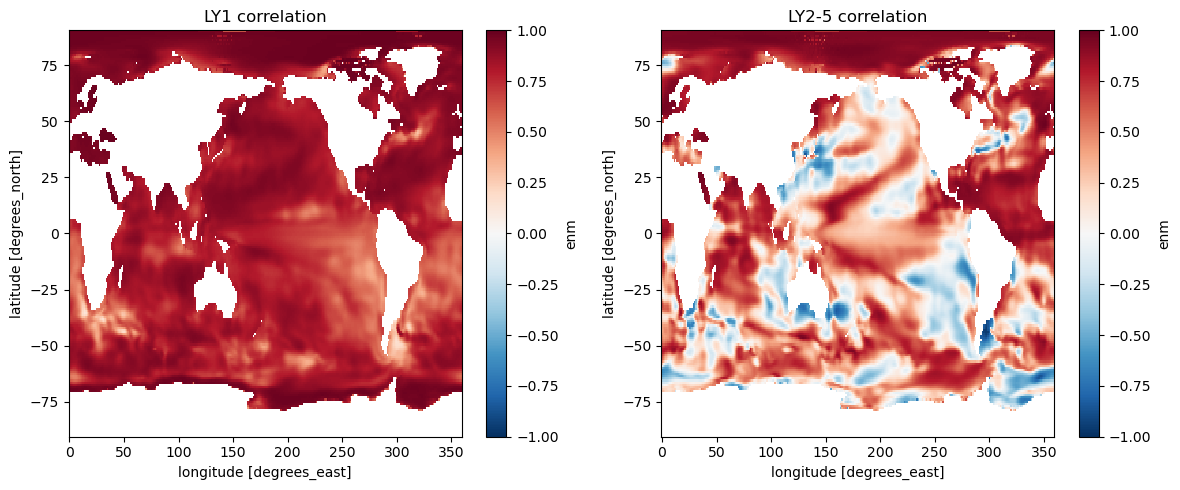


⏱ elapsed time: 1784.3413488864899


In [55]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import time

############################################################
# 🔧 helper: valid year 찾기
############################################################
def get_valid_years(da, dim='year'):
    valid = []
    broken = []

    for i in range(da.sizes[dim]):
        try:
            da.isel({dim: i}).load()
            valid.append(i)
        except Exception:
            print(f"💥 Broken → {dim}_idx={i}")
            broken.append(i)

    print("\n📊 Broken year index:", broken)
    return valid


############################################################
# 🚀 MAIN
############################################################
start_time = time.time()

# ================================
# 1. LY1 clean + corr
# ================================
hcst1 = hcst_full_ly1_annual_mean['enm']
oda1  = oda_full_annual_mean['enm']

valid_hcst1 = get_valid_years(hcst1)
valid_oda1  = get_valid_years(oda1)

valid_year1 = sorted(set(valid_hcst1) & set(valid_oda1))

hcst1_clean = hcst1.isel(year=valid_year1).load()
oda1_clean  = oda1.isel(year=valid_year1).load()

pp_HCST_enm = xr.corr(hcst1_clean, oda1_clean, dim='year')


# ================================
# 2. LY2-5 clean + corr
# ================================
common_years = np.intersect1d(
    hcst_full_ly2_5_annual_mean['year'],
    oda_full_rolling_mean['year']
)

hcst2 = hcst_full_ly2_5_annual_mean['enm'].sel(year=common_years)
oda2  = oda_full_rolling_mean['enm'].sel(year=common_years)

valid_hcst2 = get_valid_years(hcst2)
valid_oda2  = get_valid_years(oda2)

valid_year2 = sorted(set(valid_hcst2) & set(valid_oda2))

hcst2_clean = hcst2.isel(year=valid_year2).load()
oda2_clean  = oda2.isel(year=valid_year2).load()

pp_HCST_ly2_5_enm = xr.corr(hcst2_clean, oda2_clean, dim='year')


# ================================
# 3. plot
# ================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pp_HCST_enm.plot(cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("LY1 correlation")

plt.subplot(1,2,2)
pp_HCST_ly2_5_enm.plot(cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("LY2-5 correlation")

plt.tight_layout()
plt.show()


# ================================
# 4. timing
# ================================
end_time = time.time()
print('\n⏱ elapsed time:', end_time - start_time)

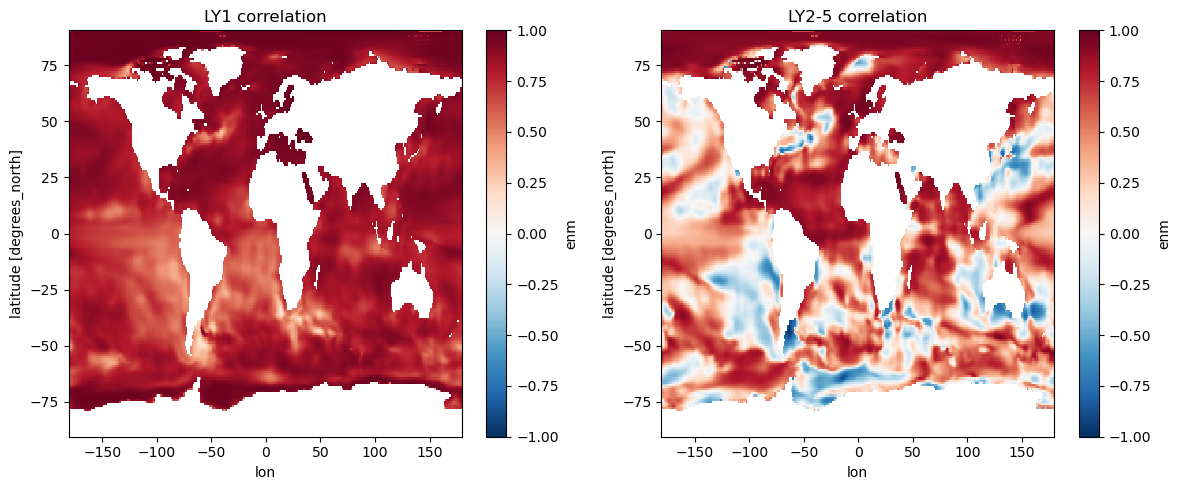

In [56]:
import matplotlib.pyplot as plt

# ---------------------------
# longitude shift (0~360 → -180~180)
# ---------------------------
def shift_lon(da):
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')

pp1 = shift_lon(pp_HCST_enm)
pp2 = shift_lon(pp_HCST_ly2_5_enm)

# ---------------------------
# plot
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pp1.plot(cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("LY1 correlation")

plt.subplot(1,2,2)
pp2.plot(cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("LY2-5 correlation")

plt.tight_layout()
plt.show()

In [53]:
start_time = time.time()

# pp_HCST = xr.corr(hcst_full_ly1_annual_mean, oda_full_annual_mean[cfg_var.var], dim='year').compute()
pp_HCST_enm = xr.corr(hcst_full_ly1_annual_mean['enm'], oda_full_annual_mean['enm'], dim='year')

common_years = np.intersect1d(hcst_full_ly2_5_annual_mean['year'], oda_full_rolling_mean['year'])
# pp_HCST_ly2_5 = xr.corr(
#     hcst_full_ly2_5_annual_mean.sel(year=common_years),
#     oda_full_rolling_mean[cfg_var.var].sel(year=common_years),
#     dim='year'
# ).compute()
pp_HCST_ly2_5_enm = xr.corr(
    hcst_full_ly2_5_annual_mean['enm'].sel(year=common_years),
    oda_full_rolling_mean['enm'].sel(year=common_years),
    dim='year'
)

# pp_HCST_ly2_5 = xr.corr(hcst_full_ly2_5_annual_mean, oda_full_rolling_mean[cfg_var.var], dim='year').compute()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for calculating correlation: ' + str(elapsed_time))

elasped time for calculating correlation: 0.25378990173339844


In [ ]:
def pop_add_cyclic(da):
        #copied from Mattew Longs github (https://gist.github.com/matt-long/50433da346da8ac17cde926eec90a87c) and modified for DA
        #This doesn't work with Dask (DA should be loaded)
        #Input DA must have the name and coords (TLONG and TLAT), and don't have other dims (time etc.)
        #Output is DA
        nj = da.TLAT.shape[0]
        ni = da.TLONG.shape[1]
        xL = int(ni/2 - 1)
        xR = int(xL + ni)
        tlon = da.TLONG.data
        tlat = da.TLAT.data
        tlon = np.where(np.greater_equal(tlon, min(tlon[:,0])), tlon-360., tlon)
        lon  = np.concatenate((tlon, tlon + 360.), 1)
        lon = lon[:, xL:xR]
        if ni == 320:
            lon[367:-3, 0] = lon[367:-3, 0] + 360.
        lon = lon - 360.
        lon = np.hstack((lon, lon[:, 0:1] + 360.))
        if ni == 320:
            lon[367:, -1] = lon[367:, -1] - 360.
        #-- trick cartopy into doing the right thing:
        #   it gets confused when the cyclic coords are identical
        lon[:, 0] = lon[:, 0] - 1e-8
        #-- periodicity
        lat = np.concatenate((tlat, tlat), 1)
        lat = lat[:, xL:xR]
        lat = np.hstack((lat, lat[:,0:1]))
        TLAT = xr.DataArray(lat, dims=('nlat', 'nlon'))
        TLONG = xr.DataArray(lon, dims=('nlat', 'nlon'))
        # copy vars
        v = da.name
        v_dims = da.dims
        # determine and sort other dimensions
        other_dims = set(v_dims) - {'nlat', 'nlon'}
        other_dims = tuple([d for d in v_dims if d in other_dims])
        lon_dim = da.dims.index('nlon')
        field = da.data
        field = np.concatenate((field, field), lon_dim)
        field = field[:, xL:xR]
        field = np.concatenate((field, field[:, 0:1]), lon_dim)
        dao = xr.DataArray(field, dims=other_dims+('nlat', 'nlon'), attrs=da.attrs)
        dao = dao.assign_coords(TLONG=TLONG)
        dao = dao.assign_coords(TLAT=TLAT)
        return dao

In [ ]:
# plot for HCST (LY1)

start_time = time.time()


varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array=corr_HCST.median(dim='ens_HCST')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    # plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=0.05, vmin=-0.05,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)

else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST<->OBS)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for calculating correlation: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY1, projd only)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array=corr_HCST.isel(ens_HCST=slice(10, 20)).median(dim='ens_HCST')


data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    # plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=0.05, vmin=-0.05,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)

else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST<->OBS)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for calculating correlation: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY2-5)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array=corr_HCST_ly2_5.median(dim='ens_HCST')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)

else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST_ly2_5<->OBS)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for calculating correlation: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY2-5, projd only)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array=corr_HCST_ly2_5.isel(ens_HCST=slice(10, 20)).median(dim='ens_HCST')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)

else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST_ly2_5<->OBS)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY1, potential predictability, all member)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# data_array=pp_HCST.mean(dim='ens_HCST').mean(dim='ens_ODA')
data_array = pp_HCST.stack(ens_combined=('ens_HCST', 'ens_ODA')).median(dim='ens_combined')
data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY1, potential predictability, all member)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# data_array=pp_HCST.mean(dim='ens_HCST').mean(dim='ens_ODA')
data_array = pp_HCST.stack(ens_combined=('ens_HCST', 'ens_ODA')).median(dim='ens_combined')
data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

# 색상 범위를 정의합니다. -1에서 1까지 10개의 구간을 가집니다.
cmap_colors = [
    '#08306B', '#08519C', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1', '#C6DBEF', '#DEEBF7', '#F7FBFF',
    '#FFF5F0', '#FEE0D2', '#FCBBA1', '#FC9272', '#FB6A4A', '#EF3B2C', '#CB181D', '#A50F15', '#67000D'
]
# 컬러 맵과 범위를 정의합니다.
cmap = mcolors.ListedColormap(cmap_colors)
bounds = np.linspace(-1, 1, len(cmap_colors)+1)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N, clip=True)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cmap, add_colorbar=False)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

# cbar_a_c = fig.add_axes([0.15, 0.95, 0.7, 0.02])  # [left, bottom, width, height] 비율로 컬러바 위치와 크기 설정


cbar1 = fig.colorbar(plt1, cmap=cmap, norm=norm, boundaries=bounds, ticks=bounds, spacing='uniform', orientation='horizontal')
cbar1.set_ticks(np.linspace(-1, 1, 21))  # -1에서 1까지 20개 구간으로 틱 설정
cbar1.set_label('R')

ax2.set_title(f'{varn} (corr, HCST<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))



In [ ]:
# plot for HCST (LY1, potential predictability, projd only)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# # ens_HCST 차원에서 0~10 인덱스에 해당하는 값들을 선택
# data_array = pp_HCST.isel(ens_HCST=slice(10, 20)).mean(dim='ens_HCST')
# # ens_ODA 차원에서도 0~10 인덱스를 선택하고 평균 계산
# data_array = data_array.isel(ens_ODA=slice(10, 20)).mean(dim='ens_ODA')

data_array = pp_HCST.isel(ens_HCST=slice(10, 20), ens_ODA=slice(10, 20)).stack(ens_combined=('ens_HCST', 'ens_ODA')).median(dim='ens_combined')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY2-5, potential predictability, all member)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array=pp_HCST_ly2_5.mean(dim='ens_HCST').mean(dim='ens_ODA')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST(ly2-5)<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))

In [ ]:
# plot for HCST (LY1, potential predictability, all member)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

# data_array=pp_HCST.mean(dim='ens_HCST').mean(dim='ens_ODA')
data_array = pp_HCST_ly2_5.stack(ens_combined=('ens_HCST', 'ens_ODA')).median(dim='ens_combined')
data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

# 색상 범위를 정의합니다. -1에서 1까지 10개의 구간을 가집니다.
cmap_colors = [
    '#08306B', '#08519C', '#2171B5', '#4292C6', '#6BAED6', '#9ECAE1', '#C6DBEF', '#DEEBF7', '#F7FBFF',
    '#FFF5F0', '#FEE0D2', '#FCBBA1', '#FC9272', '#FB6A4A', '#EF3B2C', '#CB181D', '#A50F15', '#67000D'
]
# 컬러 맵과 범위를 정의합니다.
cmap = mcolors.ListedColormap(cmap_colors)
bounds = np.linspace(-1, 1, len(cmap_colors)+1)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap.N, clip=True)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cmap, add_colorbar=False)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

# cbar_a_c = fig.add_axes([0.15, 0.95, 0.7, 0.02])  # [left, bottom, width, height] 비율로 컬러바 위치와 크기 설정


cbar1 = fig.colorbar(plt1, cmap=cmap, norm=norm, boundaries=bounds, ticks=bounds, spacing='uniform', orientation='horizontal')
cbar1.set_ticks(np.linspace(-1, 1, 21))  # -1에서 1까지 20개 구간으로 틱 설정
cbar1.set_label('R')

ax2.set_title(f'{varn} (corr, HCST<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))



In [ ]:
# plot for HCST (LY2-5, potential predictability, projd only)

start_time = time.time()

varn=cfg_var.var #example

if cfg_var.comp=='ocn':
    ds_grid = pop_tools.get_grid('POP_gx1v7')

data_array = pp_HCST_ly2_5.isel(ens_HCST=slice(10, 20)).mean(dim='ens_HCST')
data_array = data_array.isel(ens_ODA=slice(10, 20)).mean(dim='ens_ODA')

data_array.attrs['name'] = cfg_var.var

if cfg_var.var == 'SST':
    data_array = data_array.where(data_array != 0, np.nan)
if cfg_var.comp=='ocn':
    data_array['TLONG']=ds_grid.TLONG
    data_array['TLAT']=ds_grid.TLAT

projection = ccrs.Robinson(central_longitude=200)

plt.rcParams.update({'font.size': 8.5})
fig, ax2 = plt.subplots(1, 1, figsize=(18.5, 9), dpi=200, facecolor='w', edgecolor='k', subplot_kw={'projection': projection})

cbar_kwargs={'orientation':'horizontal','pad':0.05,'shrink':0.7, 'label':' R ', 'aspect':33, 'extend': 'both'}
if cfg_var.comp=='ocn' or cfg_var.comp=='ice':
    plt1=pop_add_cyclic(data_array).plot.pcolormesh(x='TLONG', y='TLAT', ax=ax2, transform=ccrs.PlateCarree(), vmax=1, vmin=-1,cmap=cm.vik, cbar_kwargs=cbar_kwargs)
else:
    plt1=data_array.isel(concat_dim=0).mean(dim='time').plot.pcolormesh(ax=ax2, transform=ccrs.PlateCarree(), vmax=30, vmin=0, cmap=cmocean.cm.deep, cbar_kwargs=cbar_kwargs)

ax2.set_title(f'{varn} (corr, HCST(ly2-5)<->ODA)')
ax2.gridlines(draw_labels=True) 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}°'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}°'))

plt.show()

end_time = time.time()
elapsed_time = end_time - start_time
print('elasped time for plot: ' + str(elapsed_time))